### Data A

<Axes: >

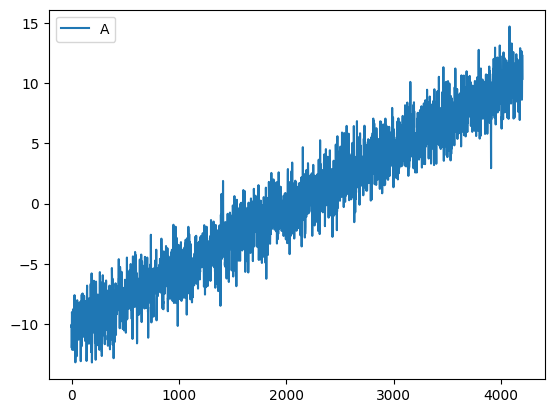

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('recitations_data_A.csv')
df.plot()

In [36]:
import statsmodels.api as sm

X = pd.DataFrame(df.iloc[:, 0])
X = sm.add_constant(X)
y = (df.iloc[:, 1])

X = X.drop('Date', axis =1).reset_index()

lr = sm.OLS(y, X).fit()
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                      A   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                 7.450e+04
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:16:47   Log-Likelihood:                -7489.7
No. Observations:                4200   AIC:                         1.498e+04
Df Residuals:                    4198   BIC:                         1.500e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
index          0.0050   1.83e-05    272.943      0.0

In [37]:
print(lr.params)

index     0.005002
const   -10.460860
dtype: float64


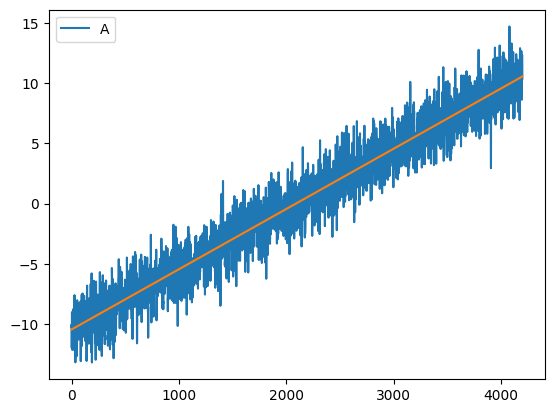

In [41]:
def lin_reg(x):
    return 0.005002*x - 10.460860

x = np.linspace(1, 4200, 4200)

df.plot()
plt.plot(x, lin_reg(x))


Text(0.5, 1.0, 'Time Series with Removed Trend Component')

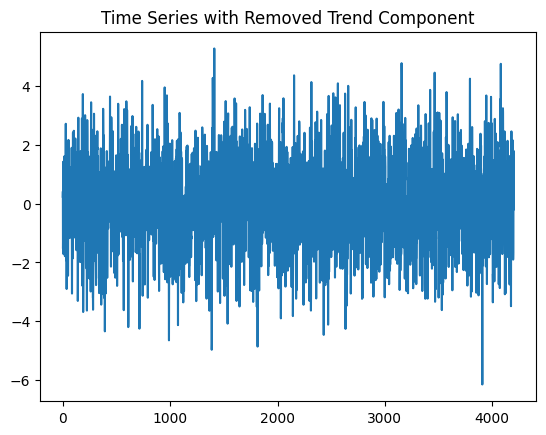

In [46]:
# remove the trend component of the time series

df['B'] = df['A'] - (df.index *0.005002 - 10.460860)
df['B'].plot()
plt.title('Time Series with Removed Trend Component')

### Data B

<Axes: >

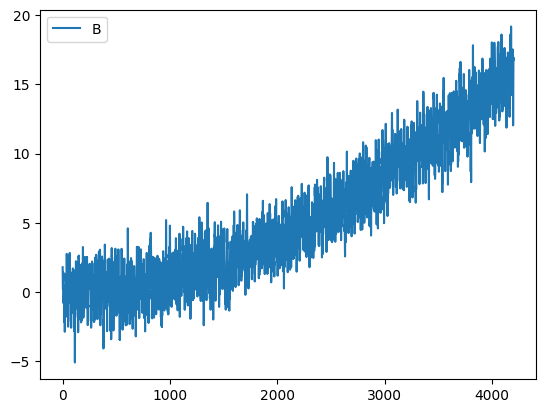

In [73]:
df = pd.read_csv('recitations_data_B.csv')
df.plot()

In [75]:
X = np.linspace(0, 4199, 4200)
X2 = X**2
X = np.column_stack((X, X2))
X = sm.add_constant(X)
y = np.array(df['B'])

print(X.shape, y.shape)

lr = sm.OLS(y, X).fit()
print(lr.summary())

(4200, 3) (4200,)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.920
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                 2.429e+04
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:25:02   Log-Likelihood:                -7434.4
No. Observations:                4200   AIC:                         1.487e+04
Df Residuals:                    4197   BIC:                         1.489e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0760      0.066  

In [77]:
lr.params

array([-7.59762843e-02,  1.82454035e-04,  8.78499806e-07])

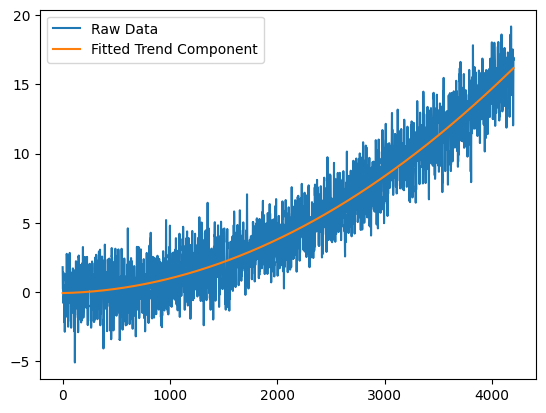

In [84]:
def data_function(x):
    return -7.59762843e-02 + 1.82454035e-04*x + 8.78499806e-07*x**2


x = np.linspace(0, 4199, 4200)

plt.plot(df['B'], label='Raw Data')
plt.plot(x, data_function(x), label='Fitted Trend Component')
plt.legend()

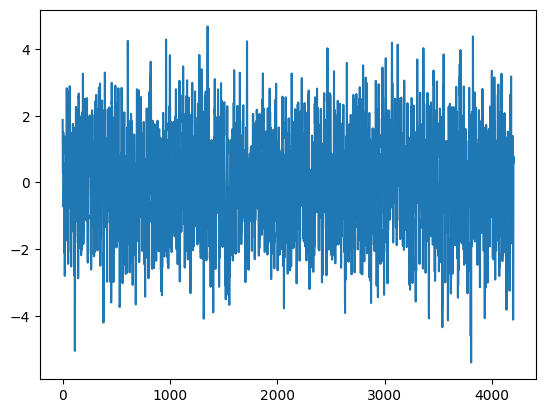

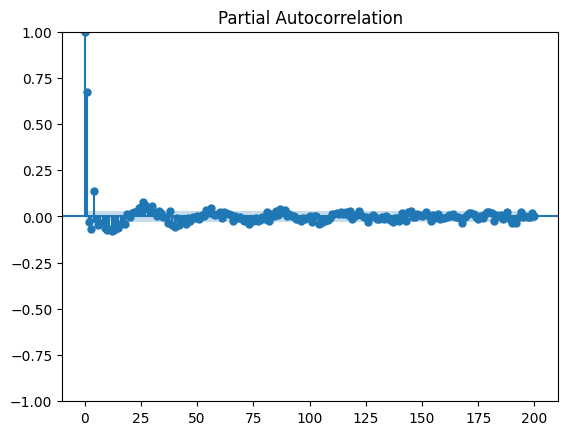

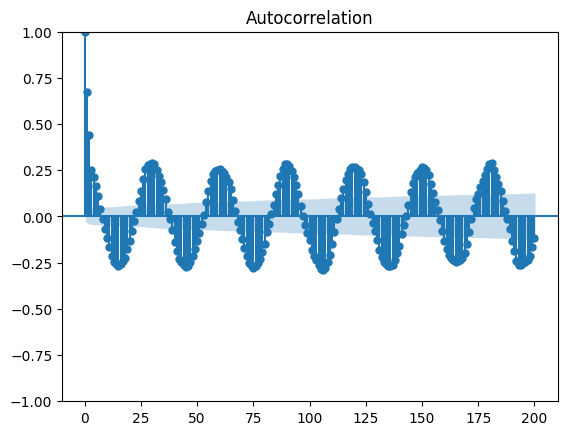

In [105]:
df['C'] = df.index
df['C'] = df['C'].apply(data_function)
df['C'] = df['B'] - df['C']
df['C'].plot()

from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

plot_pacf(df['C'], lags=200)
plt.show()

plot_acf(df['C'], lags=200)
plt.show()

np.float64(30.0)

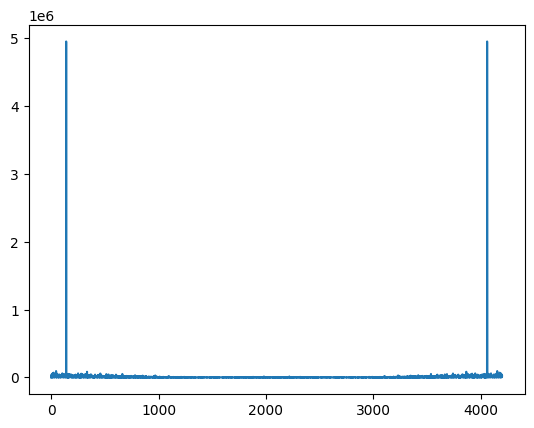

In [112]:
from scipy import signal


plt.plot(np.abs(np.fft.fft(df['C']))**2)

# here we can see the monthly seasonality trend is around 30 days
len(df['C']) /  np.argmax(np.abs(np.fft.fft(df['C'])[:1000])**2)


### Data C

<Axes: >

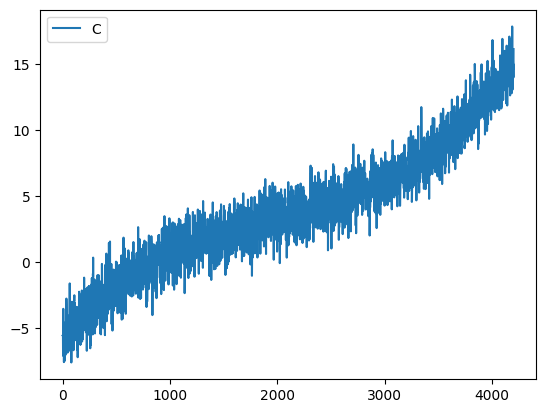

In [5]:
df = pd.read_csv('recitations_data_C.csv')
df.plot()

### Air Quality Modelling

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from ucimlrepo import fetch_ucirepo

air_quality = fetch_ucirepo(id=360)


# data (as pandas dataframes)
air_data = air_quality.data.features
air_data['date'] = pd.to_datetime(air_data.apply(lambda x: x['Date'] + " " + x['Time'], axis=1))
air_data = air_data.set_index("date")

DatasetNotFoundError: Error reading data csv file for "Air Quality" dataset (id=360).